In [1]:
import os
import numpy as np
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TF version: 2.20.0
GPU devices: []


In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("x_train:", x_train.shape, x_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_test :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
x_train: (60000, 28, 28) uint8
y_train: (60000,) uint8
x_test : (10000, 28, 28)


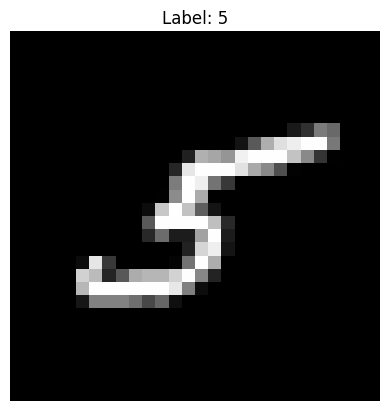

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [7]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print(x_train.min(), x_train.max())

0.0 1.0


In [8]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),                  # (28,28) -> (784,)
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()]
)

In [10]:
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    verbose=1
)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3545 - sparse_categorical_accuracy: 0.8997 - val_loss: 0.1454 - val_sparse_categorical_accuracy: 0.9588
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1469 - sparse_categorical_accuracy: 0.9567 - val_loss: 0.1057 - val_sparse_categorical_accuracy: 0.9697
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1019 - sparse_categorical_accuracy: 0.9696 - val_loss: 0.1021 - val_sparse_categorical_accuracy: 0.9705
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0780 - sparse_categorical_accuracy: 0.9768 - val_loss: 0.0866 - val_sparse_categorical_accuracy: 0.9737
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0619 - sparse_categorical_accuracy: 0.9815 - val_loss: 0.0842 - val_sparse_categorical_accuracy: 0.9772
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0485 - sparse_categorical_accuracy: 0.9850 - val_loss: 0.0872 - val_sparse_categorical_accuracy: 0.9750
Epoch 7/8


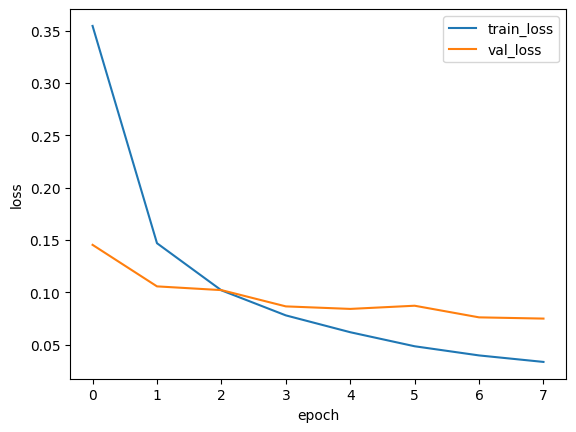

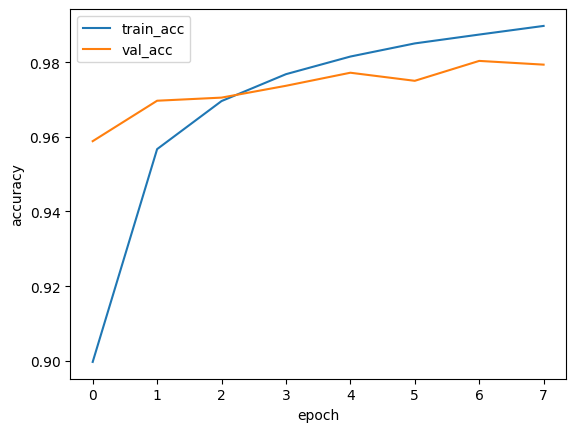

In [11]:
hist = history.history

plt.figure()
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["sparse_categorical_accuracy"], label="train_acc")
plt.plot(hist["val_sparse_categorical_accuracy"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test acc :", test_acc)

Test loss: 0.07553624361753464
Test acc : 0.9768999814987183


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

y_prob = model.predict(x_test, verbose=0)        # (10000, 10)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

[[ 967    0    1    2    2    1    3    0    2    2]
 [   0 1122    2    3    1    1    1    2    3    0]
 [   5    6 1001    2    2    1    2   10    3    0]
 [   0    0    5  988    0    2    0    6    6    3]
 [   1    0    1    1  966    0    2    3    1    7]
 [   3    0    0   11    2  862    3    1    7    3]
 [   7    3    2    1    7    3  930    2    3    0]
 [   1    2    5    2    0    0    0 1010    0    8]
 [   1    2    2    9    2    3    2    5  944    4]
 [   0    5    0    4   10    4    0    6    1  979]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.97      0.97       892
           6       0.99      0.97      0.98       958
           7       0.97      0.98   